# LunaTech — Geometry-Aware Lunar Correspondence Engine
### SIH 26166 · Prototype v3 · Real Chandrayaan-2 OHRC imagery

**Problem statement:** *Multi-modal, Sun-angle and scale-invariant image correspondence using Chandrayaan-2 optical images (OHRC, TMC-2, IIRS).* Evaluation criteria named in the PS: **sub-pixel RMSE**, **inlier count / ratio**, and **uniform spatial distribution** of matches.

---

## Executive summary

This notebook runs the full LunaTech registration pipeline end-to-end on **real OHRC surface crops** and reports every metric the PS asks for, plus the evidence needed to trust them:

| What you'll see | Where | Why it matters to a reviewer |
|---|---|---|
| The dataset, inspected before anything is trusted | §1 | No claim is built on an unverified assumption about the data |
| A crater-detector sanity check against **real annotated craters** | §2 | The structural verifier is validated, not assumed |
| Exact ground truth from self-supervised pairs | §3 | Every accuracy number is measured against a *known* transform |
| The pipeline running stage-by-stage on one pair, with a **match-survival funnel**, **coverage heatmaps** and **error distributions** | §4–§5 | Shows what each stage does, not just the final number |
| A **per-stage ablation** over many pairs | §6 | Quantifies what each stage contributes to which metric |
| A **stress matrix** (illumination × scale, repeated) | §7 | One accuracy number is not a benchmark |
| A results scorecard and an explicit limitations list | §8–§9 | Headline numbers, with their caveats attached |

**Data source:** [`piyushsharma5654/ohrc-images-chandaryaan-2`](https://www.kaggle.com/datasets/piyushsharma5654/ohrc-images-chandaryaan-2) — PNG OHRC patches with XML crater annotations. This is a community-curated crop set, **not** the PDS4 archive: there is no per-image geometry, SPICE, or Sun-angle metadata. §0.2 states exactly what that does and doesn't let us claim.

## 0.1 · Pipeline at a glance

LunaTech is organised as the **CRATER** model. In this notebook the stages run in the order that makes sense for a prototype (geometric verification before structural, so the structural check sees a clean inlier set):

- **C — Candidate generation** (Stage 3): appearance matching. SIFT + Lowe ratio test here — the classical baseline. The function signature is fixed so a learned matcher (LoFTR / LightGlue) is a drop-in replacement.
- **A — Adaptive geometric modelling** (Stage 5): RANSAC homography rejects geometrically inconsistent candidates.
- **R — Robust structural verification** (Stage 4): a crater-neighbourhood signature check — a match must preserve the *layout of nearby craters*, not just look similar. This is the illumination-robust idea; appearance can change with the Sun, crater topology cannot.
- **T — Targeted spatial optimisation** (Stage 6): grid-quota selection forces matches to be spread across the frame instead of clustering on textured patches. Directly targets the PS's "uniform distribution" criterion.
- **E — Enhanced sub-pixel refinement** (Stage 7): local phase correlation lifts integer-pixel matches to sub-pixel precision. This is what earns the "sub-pixel" claim.
- **R — Registered output & reporting**: metrics, funnel, coverage, stress matrix.

In [17]:
import os, glob, time, random, itertools, warnings
import xml.etree.ElementTree as ET
from dataclasses import dataclass, asdict

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib import cm, colors as mcolors
from skimage.feature import blob_log
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# ---- LunaTech visual theme -----------------------------------------------
NAVY, TEAL, CYAN, AMBER, CORAL, GREY, LINE = "#13223B", "#0E7C93", "#4FD8EB", "#C8862B", "#C24444", "#8792A6", "#D8DEE9"
PALETTE = [NAVY, TEAL, AMBER, CORAL, GREY, CYAN]

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": LINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": LINE, "grid.alpha": 0.6, "grid.linewidth": 0.6,
    "axes.titleweight": "bold", "axes.titlecolor": NAVY, "axes.titlesize": 11,
    "axes.labelcolor": "#3A4A63", "xtick.color": "#3A4A63", "ytick.color": "#3A4A63",
    "font.size": 10, "legend.frameon": False,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
})

def fig_title(fig, title, subtitle=None, y=1.02):
    fig.suptitle(title, fontsize=13, weight="bold", color=NAVY, x=0.01, ha="left", y=y)
    if subtitle:
        fig.text(0.01, y - 0.30 / fig.get_figheight(), subtitle, fontsize=9.5, color=GREY, ha="left")

def show_img(ax, img, title=None):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=9.5)

rng = np.random.default_rng(42)
print("OpenCV", cv2.__version__, "| SIFT available:", hasattr(cv2, "SIFT_create"))

OpenCV 4.13.0 | SIFT available: True


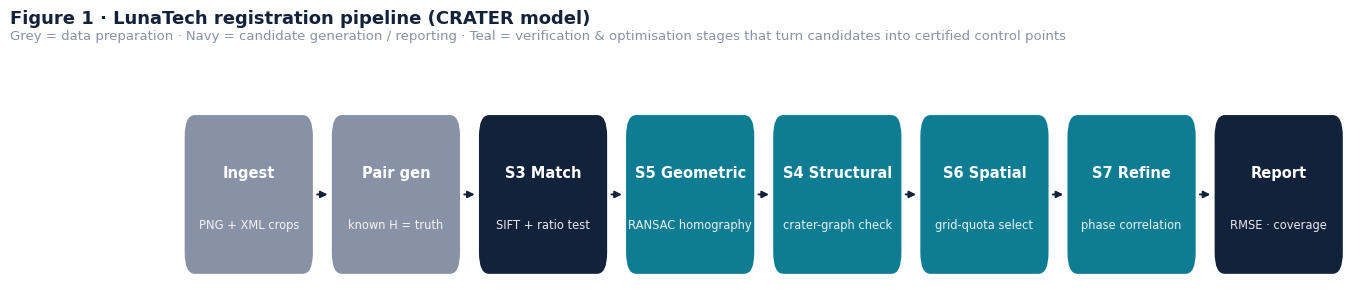

In [18]:
def draw_pipeline():
    stages = [("Ingest", "PNG + XML crops"), ("Pair gen", "known H = truth"),
              ("S3 Match", "SIFT + ratio test"), ("S5 Geometric", "RANSAC homography"),
              ("S4 Structural", "crater-graph check"), ("S6 Spatial", "grid-quota select"),
              ("S7 Refine", "phase correlation"), ("Report", "RMSE · coverage")]
    fills = [GREY, GREY, NAVY, TEAL, TEAL, TEAL, TEAL, NAVY]
    fig, ax = plt.subplots(figsize=(15, 2.3)); ax.set_axis_off(); ax.grid(False)
    w, gap = 1.72, 0.3
    for i, ((t, s), c) in enumerate(zip(stages, fills)):
        x = i * (w + gap)
        ax.add_patch(FancyBboxPatch((x, 0), w, 1, boxstyle="round,pad=0.02,rounding_size=0.14", fc=c, ec="none"))
        ax.text(x + w / 2, 0.64, t, ha="center", va="center", color="white", fontsize=10.5, weight="bold")
        ax.text(x + w / 2, 0.30, s, ha="center", va="center", color="white", fontsize=8.3, alpha=0.9)
        if i < len(stages) - 1:
            ax.annotate("", xy=(x + w + gap - 0.04, 0.5), xytext=(x + w + 0.04, 0.5),
                        arrowprops=dict(arrowstyle="-|>", color=NAVY, lw=1.4))
    ax.set_xlim(-0.05, len(stages) * (w + gap) - gap + 0.05); ax.set_ylim(-0.08, 1.08)
    fig_title(fig, "Figure 1 · LunaTech registration pipeline (CRATER model)",
              "Grey = data preparation · Navy = candidate generation / reporting · Teal = verification & optimisation stages that turn candidates into certified control points", y=1.3)
    plt.show()

draw_pipeline()

## 0.2 · Scope, assumptions and what this notebook does *not* claim

Stated up front so every number below can be read with the right confidence level.

| Aspect | Status in this notebook | Implication |
|---|---|---|
| Source imagery | Real OHRC surface crops (community Kaggle set) | Texture, crater morphology and noise are real — the matcher is exercised on genuine lunar appearance |
| Geometric ground truth | **Exact** — each test pair is built by warping a real crop with a *known* homography (standard self-supervision trick) | Every RMSE / inlier number is measured against truth, not estimated |
| Illumination difference | **Photometric proxy** — independent brightness / gamma / contrast / noise perturbation per image | Models exposure & tone change. Does **not** model shadow direction or length changing with Sun angle — that needs a DEM, which this dataset lacks |
| Pixel size (GSD) | OHRC nominal ≈ 0.25 m/px, **unverified** for these pre-cropped patches | Pixel metrics are exact; metre metrics are labelled *approx.* and are not headline claims |
| Repeat-pass real pairs | Not available in this dataset | Genuine Sun-angle robustness is validated in the roadmap step (PRADAN repeat passes), not here |
| Crater ground truth | Real XML annotations | Used to *validate the structural verifier's detector* (§2), a check the synthetic prototype could not do |

Everything else — the pipeline, the metrics, the ablation and the stress matrix — is measured, not asserted.

## 0.3 · Configuration

One dataclass holds every tunable. `DATA_DIR` is auto-detected under `/kaggle/input/`; outside Kaggle a small synthetic stand-in is generated so the notebook still executes end-to-end (it will say so loudly).

In [19]:
@dataclass
class Config:
    tile_size: int = 512                 # working crop size
    border_margin: int = 8               # px trimmed from each real-image edge
    min_gray_unique_values: int = 20     # below this an image is treated as binary / segmented
    pixel_size_m: float = 0.25           # nominal OHRC GSD — UNVERIFIED for this dataset
    report_meters: bool = True
    # Stage 3 — appearance matching
    sift_n_features: int = 4000
    lowe_ratio: float = 0.75
    # Stage 4 — structural verification
    blob_min_sigma: float = 3.0
    blob_max_sigma: float = 12.0
    blob_threshold: float = 0.02
    structural_neighbor_k: int = 4
    structural_tol: float = 0.35
    # Stage 5 — geometric verification
    ransac_reproj_thresh: float = 3.0
    # Stage 6 — spatial optimisation
    grid_size: int = 6
    max_per_cell: int = 6
    # Stage 7 — sub-pixel refinement
    refine_win: int = 15
    refine_max_shift: float = 2.5          # px — larger phase-correlation shifts are treated as failures
    # Experiments
    runtime_budget_s: float = 5.0
    n_ablation_pairs: int = 10
    stress_repeats: int = 3

CFG = Config()
pd.DataFrame(asdict(CFG).items(), columns=["parameter", "value"]).set_index("parameter").T

parameter,tile_size,border_margin,min_gray_unique_values,pixel_size_m,report_meters,sift_n_features,lowe_ratio,blob_min_sigma,blob_max_sigma,blob_threshold,structural_neighbor_k,structural_tol,ransac_reproj_thresh,grid_size,max_per_cell,refine_win,refine_max_shift,runtime_budget_s,n_ablation_pairs,stress_repeats
value,512,8,20,0.25,True,4000,0.75,3.0,12.0,0.02,4,0.35,3.0,6,6,15,2.5,5.0,10,3


## §1 · Dataset — inspect before trusting

Recursively locates the PNG/XML pairs, then separates **photometric grayscale imagery** (usable for matching) from **binary / segmented masks** (no texture for a matcher to key on). The split is heuristic — number of distinct intensity values — because the dataset has no reliable filename convention. The overview figure is the check.

In [20]:
CANDIDATE_ROOTS = ["/kaggle/input/datasets/piyushsharma5654/ohrc-images-chandaryaan-2", "/kaggle/input/ohrc-images-chandaryaan2"]
if os.path.isdir("/kaggle/input"):
    CANDIDATE_ROOTS += [os.path.join("/kaggle/input", d) for d in os.listdir("/kaggle/input") if "ohrc" in d.lower()]
DATA_DIR = next((d for d in CANDIDATE_ROOTS if os.path.isdir(d)), None)
USING_FALLBACK = DATA_DIR is None

if USING_FALLBACK:
    print("=" * 78)
    print("REAL DATASET NOT FOUND under /kaggle/input — generating a synthetic stand-in so the")
    print("code can be exercised. On Kaggle with the dataset attached this must NOT happen.")
    print("=" * 78)
    DATA_DIR = "/tmp/ohrc_fallback"; os.makedirs(DATA_DIR, exist_ok=True)

    def _fake_crater_image(path, size=640, n_craters=8, binary=False, seed=0):
        rs = np.random.default_rng(seed)
        img = np.full((size, size), 120, dtype=np.uint8); craters = []
        for _ in range(n_craters):
            cx, cy = rs.integers(40, size - 40, size=2); r = int(rs.integers(10, 50))
            if binary:
                cv2.circle(img, (cx, cy), r, 255, -1)
            else:
                cv2.circle(img, (cx, cy), r, 60, -1); cv2.circle(img, (cx, cy), r, 200, 2)
            craters.append((int(cx), int(cy), r))
        if not binary:
            img = np.clip(img.astype(float) + rs.normal(0, 8, size=(size, size)), 0, 255).astype(np.uint8)
        cv2.imwrite(path, img); return craters

    def _fake_xml(path, stem, craters, size=640):
        root = ET.Element("annotation"); ET.SubElement(root, "filename").text = stem + ".png"
        sz = ET.SubElement(root, "size"); ET.SubElement(sz, "width").text = str(size); ET.SubElement(sz, "height").text = str(size)
        for (cx, cy, r) in craters:
            obj = ET.SubElement(root, "object"); ET.SubElement(obj, "name").text = "crater"
            bb = ET.SubElement(obj, "bndbox")
            for k, v in zip(("xmin", "ymin", "xmax", "ymax"), (max(0, cx - r), max(0, cy - r), min(size, cx + r), min(size, cy + r))):
                ET.SubElement(bb, k).text = str(v)
            ET.SubElement(obj, "diameter").text = str(2 * r)
        ET.ElementTree(root).write(path)

    for i in range(10):
        stem = f"ohrc_patch_{i:03d}"
        _fake_xml(os.path.join(DATA_DIR, stem + ".xml"), stem, _fake_crater_image(os.path.join(DATA_DIR, stem + ".png"), seed=i))
    for i in range(2):
        _fake_crater_image(os.path.join(DATA_DIR, f"ohrc_patch_mask_{i:03d}.png"), binary=True, seed=100 + i)

all_png = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.png"), recursive=True))
all_xml = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.xml"), recursive=True))
print(f"DATA_DIR = {DATA_DIR}")
print(f"{len(all_png)} PNG files · {len(all_xml)} XML files")

DATA_DIR = /kaggle/input/datasets/piyushsharma5654/ohrc-images-chandaryaan-2
19 PNG files · 55 XML files


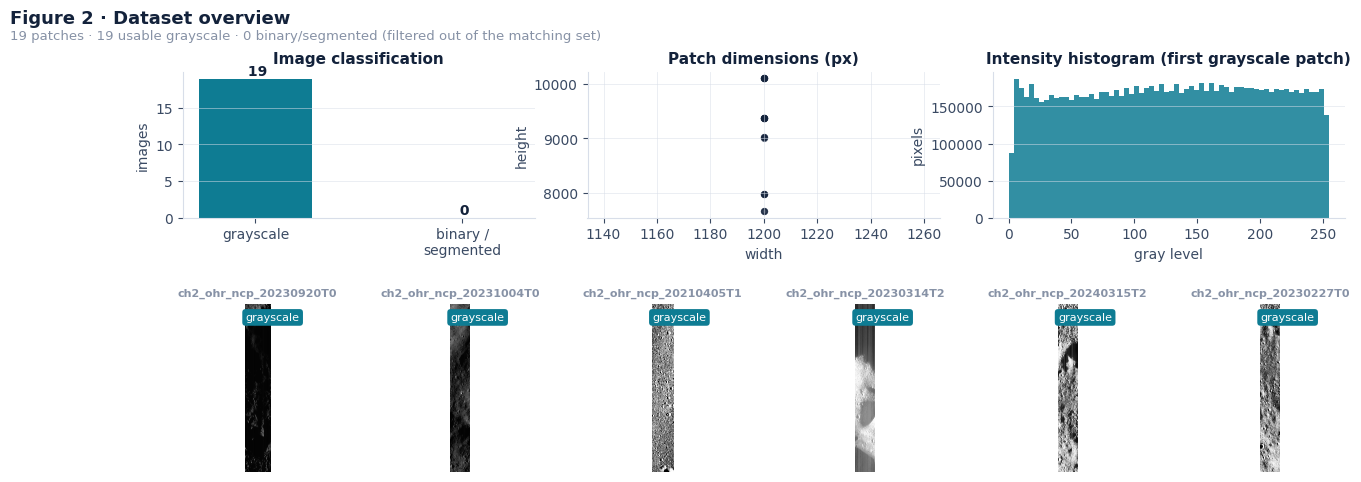

Usable grayscale images for matching: 19


In [21]:
def classify_image(path, cfg=CFG):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return "unreadable", None
    kind = "binary/segmented" if len(np.unique(img)) < cfg.min_gray_unique_values else "grayscale"
    return kind, img.shape

image_df = pd.DataFrame([{"file": p, "kind": classify_image(p)[0], "shape": classify_image(p)[1]} for p in all_png])
image_df["height"] = image_df["shape"].apply(lambda s: s[0] if s else np.nan)
image_df["width"] = image_df["shape"].apply(lambda s: s[1] if s else np.nan)
grayscale_files = image_df.loc[image_df["kind"] == "grayscale", "file"].tolist()
n_gray, n_bin = (image_df["kind"] == "grayscale").sum(), (image_df["kind"] == "binary/segmented").sum()

# ---- Figure 2: dataset overview ------------------------------------------
fig = plt.figure(figsize=(15, 5.2))
gs = fig.add_gridspec(2, 6, height_ratios=[1, 1.15], hspace=0.55, wspace=0.35)

ax = fig.add_subplot(gs[0, 0:2])
ax.bar(["grayscale", "binary /\nsegmented"], [n_gray, n_bin], color=[TEAL, GREY], width=0.55)
for i, v in enumerate([n_gray, n_bin]):
    ax.text(i, v, f" {v}", ha="center", va="bottom", fontsize=10, color=NAVY, weight="bold")
ax.set_title("Image classification"); ax.set_ylabel("images"); ax.grid(axis="x", visible=False)

ax = fig.add_subplot(gs[0, 2:4])
ax.scatter(image_df["width"], image_df["height"], s=18, alpha=0.6, color=NAVY)
ax.set_title("Patch dimensions (px)"); ax.set_xlabel("width"); ax.set_ylabel("height")

ax = fig.add_subplot(gs[0, 4:6])
vals = cv2.imread(grayscale_files[0], cv2.IMREAD_GRAYSCALE).ravel() if grayscale_files else np.array([0])
ax.hist(vals, bins=64, color=TEAL, alpha=0.85)
ax.set_title("Intensity histogram (first grayscale patch)"); ax.set_xlabel("gray level"); ax.set_ylabel("pixels"); ax.grid(axis="x", visible=False)

sample_paths = random.Random(0).sample(all_png, min(6, len(all_png)))
for j, p in enumerate(sample_paths):
    ax = fig.add_subplot(gs[1, j])
    show_img(ax, cv2.imread(p, cv2.IMREAD_GRAYSCALE))
    kind, _ = classify_image(p)
    ax.text(0.03, 0.95, kind, transform=ax.transAxes, fontsize=8, va="top", color="white",
            bbox=dict(boxstyle="round,pad=0.3", fc=TEAL if kind == "grayscale" else GREY, ec="none"))
    ax.set_title(os.path.basename(p)[:22], fontsize=8, color=GREY)

fig_title(fig, "Figure 2 · Dataset overview", f"{len(all_png)} patches · {n_gray} usable grayscale · {n_bin} binary/segmented (filtered out of the matching set)", y=1.0)
plt.show()
print(f"Usable grayscale images for matching: {len(grayscale_files)}")

## §2 · Crater annotations and detector validation

The structural verifier (Stage 4) needs crater-like structures to build its neighbourhood signatures. It uses a Laplacian-of-Gaussian blob detector — classical, no training data required. This dataset uniquely ships **real crater annotations**, so before relying on the detector we measure what fraction of annotated craters it actually recovers. This is a one-time validation of a pipeline component, not part of the per-pair pipeline.

The XML parser is deliberately generic (handles `bndbox`, `x/y/width/height` and `center + diameter` schemas) and prints the raw record it found so the schema is visible rather than assumed.

In [22]:
def parse_annotation(xml_path):
    try:
        root = ET.parse(xml_path).getroot()
    except ET.ParseError:
        return []
    objects = root.findall(".//object") or root.findall(".//crater") or list(root)
    craters = []
    for obj in objects:
        raw = {c.tag: c.text for c in obj.iter() if c.text and c.text.strip()}
        bb = obj.find("bndbox")
        if bb is not None:
            try:
                xmin, ymin, xmax, ymax = (float(bb.findtext(k)) for k in ("xmin", "ymin", "xmax", "ymax"))
                craters.append({"cx": (xmin + xmax) / 2, "cy": (ymin + ymax) / 2, "diameter": max(xmax - xmin, ymax - ymin), "raw": raw})
                continue
            except (TypeError, ValueError):
                pass
        def ff(*names):
            for n in names:
                try:
                    return float(raw[n])
                except (KeyError, ValueError, TypeError):
                    continue
            return None
        cx, cy, d = ff("x", "cx", "center_x", "xcenter"), ff("y", "cy", "center_y", "ycenter"), ff("diameter", "diam", "width")
        if cx is not None and cy is not None:
            craters.append({"cx": cx, "cy": cy, "diameter": d or 0.0, "raw": raw})
    return craters


def detect_blobs(img, cfg=CFG):
    blobs = blob_log(img.astype(float) / 255.0, min_sigma=cfg.blob_min_sigma, max_sigma=cfg.blob_max_sigma, num_sigma=5, threshold=cfg.blob_threshold)
    return np.empty((0, 2)) if len(blobs) == 0 else blobs[:, [1, 0]]  # (x, y)


def blob_recall(png_path, xml_path, tol_px=15, cfg=CFG):
    img = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
    ann = parse_annotation(xml_path) if img is not None else []
    if not ann:
        return None, None, None
    blobs = detect_blobs(img, cfg)
    if len(blobs) == 0:
        return 0.0, ann, blobs
    hits = sum(np.linalg.norm(blobs - np.array([c["cx"], c["cy"]]), axis=1).min() < tol_px for c in ann)
    return hits / len(ann), ann, blobs


paired = [(p, os.path.splitext(p)[0] + ".xml") for p in grayscale_files]
paired = [(p, x) for p, x in paired if os.path.exists(x)]
print(f"{len(paired)} grayscale images have a matching XML annotation")
if paired:
    sample_ann = parse_annotation(paired[0][1])
    print(f"Sample record from {os.path.basename(paired[0][1])}: {sample_ann[0] if sample_ann else 'none parsed — inspect raw file'}")

19 grayscale images have a matching XML annotation
Sample record from ch2_ohr_ncp_20210331T2033243734_b_brw_d18.xml: none parsed — inspect raw file


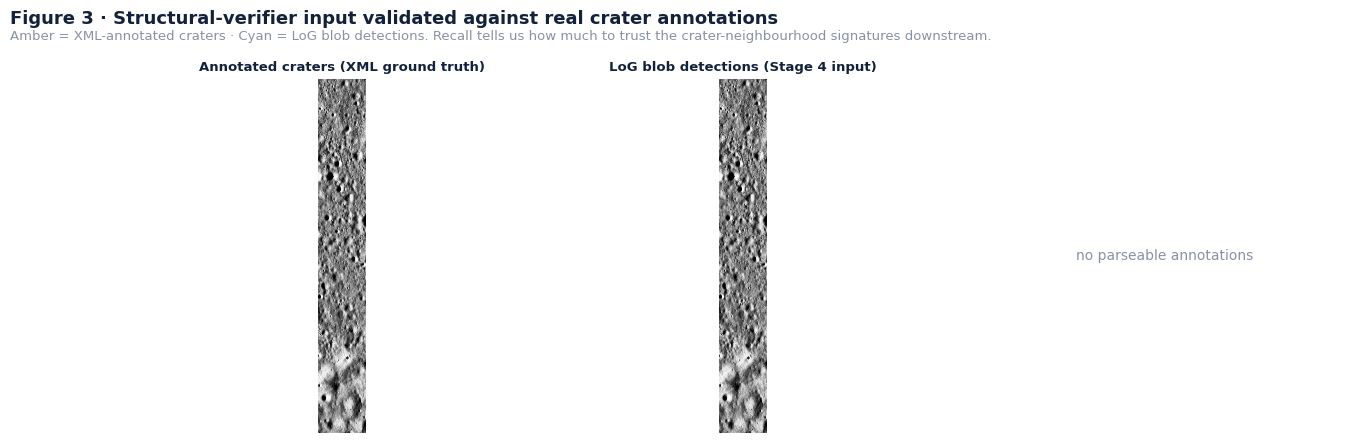

In [23]:
recall_rows = [(os.path.basename(p), r) for p, x in paired[:20] if (r := blob_recall(p, x)[0]) is not None]

fig = plt.figure(figsize=(15, 4.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.15, 1.3], wspace=0.25)

if paired:
    p0, x0 = paired[0]
    rec0, ann0, blobs0 = blob_recall(p0, x0)
    img0 = cv2.imread(p0, cv2.IMREAD_GRAYSCALE)
    ax = fig.add_subplot(gs[0, 0]); show_img(ax, img0, "Annotated craters (XML ground truth)")
    for c in (ann0 or []):
        ax.add_patch(plt.Circle((c["cx"], c["cy"]), max(c["diameter"] / 2, 4), fill=False, ec=AMBER, lw=1.4))
    ax = fig.add_subplot(gs[0, 1]); show_img(ax, img0, "LoG blob detections (Stage 4 input)")
    if blobs0 is not None and len(blobs0):
        ax.scatter(blobs0[:, 0], blobs0[:, 1], s=28, facecolors="none", edgecolors=CYAN, linewidths=1.3)
    for c in (ann0 or []):
        ax.plot(c["cx"], c["cy"], "+", color=AMBER, ms=9, mew=1.5)

ax = fig.add_subplot(gs[0, 2])
if recall_rows:
    rec_vals = np.array([r for _, r in recall_rows])
    ax.barh(range(len(rec_vals)), rec_vals, color=TEAL, alpha=0.85)
    ax.axvline(rec_vals.mean(), color=NAVY, ls="--", lw=1.3, label=f"mean = {rec_vals.mean():.2f}")
    ax.set_yticks([]); ax.set_xlim(0, 1.02); ax.set_xlabel("fraction of annotated craters recovered (±15 px)")
    ax.set_title(f"Detector recall over {len(rec_vals)} annotated images"); ax.legend(loc="lower right"); ax.grid(axis="y", visible=False)
    detector_recall_mean = float(rec_vals.mean())
else:
    ax.text(0.5, 0.5, "no parseable annotations", ha="center", va="center", color=GREY); ax.set_axis_off()
    detector_recall_mean = float("nan")

fig_title(fig, "Figure 3 · Structural-verifier input validated against real crater annotations",
          "Amber = XML-annotated craters · Cyan = LoG blob detections. Recall tells us how much to trust the crater-neighbourhood signatures downstream.", y=1.03)
plt.show()

## §3 · Test pairs with exact ground truth

To measure accuracy you need pairs whose true correspondence is *known*. Standard self-supervision trick: take a real crop as image A, warp it with a **randomly sampled but recorded homography** to produce image B, then perturb each side photometrically and independently. Because we chose the homography, the ground-truth position of every point in A is known exactly in B.

The right-hand panel below draws a reference grid on A and pushes it through the ground-truth homography onto B, so the geometric change being tested is visible rather than described.

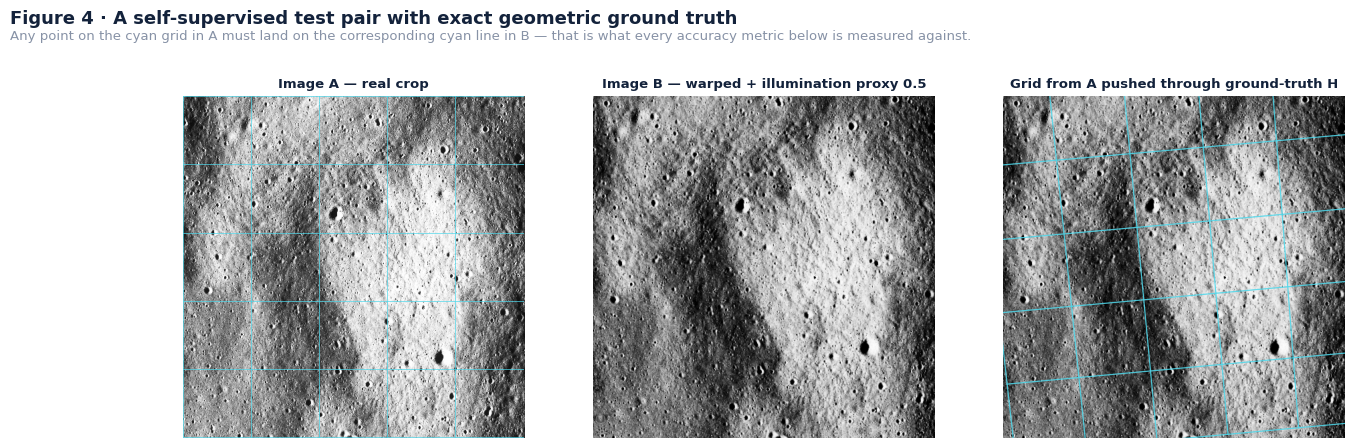

In [24]:
def random_homography(size, max_rotation_deg=8, max_scale=1.15, max_shift_frac=0.03, max_perspective=1e-4, seed=None):
    rs = np.random.default_rng(seed)
    theta = np.deg2rad(rs.uniform(-max_rotation_deg, max_rotation_deg)); scale = rs.uniform(1 / max_scale, max_scale)
    tx, ty = rs.uniform(-max_shift_frac, max_shift_frac, size=2) * size; cx = cy = size / 2
    R = np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0], [0, 0, 1]])
    S = np.diag([scale, scale, 1]); T1 = np.array([[1, 0, -cx], [0, 1, -cy], [0, 0, 1]]); T2 = np.array([[1, 0, cx + tx], [0, 1, cy + ty], [0, 0, 1]])
    P = np.array([[1, 0, 0], [0, 1, 0], [rs.uniform(-max_perspective, max_perspective), rs.uniform(-max_perspective, max_perspective), 1]])
    return T2 @ P @ S @ R @ T1


def photometric_perturb(img, illum_strength, seed=None):
    rs = np.random.default_rng(seed)
    gamma = 1.0 + rs.uniform(-0.6, 0.6) * illum_strength
    brightness = rs.uniform(-60, 60) * illum_strength
    contrast = 1.0 + rs.uniform(-0.3, 0.3) * illum_strength
    out = (img.astype(np.float32) / 255.0) ** gamma * 255.0
    out = out * contrast + brightness + rs.normal(0, 3, size=img.shape)
    return np.clip(out, 0, 255).astype(np.uint8)


def load_and_crop(path, cfg=CFG, seed=None):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    m = cfg.border_margin
    if m > 0 and min(img.shape) > 2 * m:
        img = img[m:-m, m:-m]
    ts = cfg.tile_size
    if img.shape[0] < ts or img.shape[1] < ts:
        img = cv2.resize(img, (max(ts, img.shape[1]), max(ts, img.shape[0])))
    rs = np.random.default_rng(seed)
    y0 = int(rs.integers(0, img.shape[0] - ts + 1)); x0 = int(rs.integers(0, img.shape[1] - ts + 1))
    return img[y0:y0 + ts, x0:x0 + ts]


def make_pair(src_path, seed, illum_strength=0.5, scale_ratio=1.0, cfg=CFG):
    crop = load_and_crop(src_path, cfg, seed=seed)
    if crop is None:
        return None
    H_gt = random_homography(cfg.tile_size, max_rotation_deg=6, max_scale=scale_ratio, seed=seed + 1000)
    img_b_geom = cv2.warpPerspective(crop, H_gt, (cfg.tile_size, cfg.tile_size), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    return photometric_perturb(crop, illum_strength * 0.3, seed=seed + 1), photometric_perturb(img_b_geom, illum_strength, seed=seed + 2), H_gt


def apply_H(H, pts):
    p = np.hstack([pts, np.ones((len(pts), 1))]) @ H.T
    return p[:, :2] / p[:, 2:3]


if not grayscale_files:
    raise RuntimeError("No usable grayscale images — check §1.")

DEMO_ILLUM, DEMO_SCALE = 0.5, 1.10
imgA_demo, imgB_demo, H_gt_demo = make_pair(grayscale_files[0], seed=7, illum_strength=DEMO_ILLUM, scale_ratio=DEMO_SCALE)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
show_img(axes[0], imgA_demo, "Image A — real crop")
show_img(axes[1], imgB_demo, f"Image B — warped + illumination proxy {DEMO_ILLUM}")
show_img(axes[2], imgB_demo, "Grid from A pushed through ground-truth H")
n = 6; ts = CFG.tile_size; lines = np.linspace(0, ts - 1, n)
for v in lines:
    axes[0].plot([v, v], [0, ts - 1], color=CYAN, lw=0.7, alpha=0.7); axes[0].plot([0, ts - 1], [v, v], color=CYAN, lw=0.7, alpha=0.7)
    seg = np.linspace(0, ts - 1, 40)
    for pts in (np.c_[np.full_like(seg, v), seg], np.c_[seg, np.full_like(seg, v)]):
        w = apply_H(H_gt_demo, pts); axes[2].plot(w[:, 0], w[:, 1], color=CYAN, lw=0.9, alpha=0.85)
for ax in axes:
    ax.set_xlim(0, ts); ax.set_ylim(ts, 0)
fig_title(fig, "Figure 4 · A self-supervised test pair with exact geometric ground truth",
          "Any point on the cyan grid in A must land on the corresponding cyan line in B — that is what every accuracy metric below is measured against.", y=1.01)
plt.show()

## §4 · The pipeline stages

Each stage is a plain function with a fixed input/output contract, so they can be toggled independently (used in the ablation, §6) and any single one can be swapped out — Stage 3 in particular is where a learned matcher would go.

One design point worth calling out. Naive phase-correlation refinement assumes the two patches differ by translation only; under the rotation and scale present in real pairs it returns spurious shifts and, applied blindly, *worsens* accuracy — the ablation in §6 is what caught this in an earlier version. Stage 7 is therefore **model-assisted and gated**: image B is first warped into A's frame with the RANSAC homography (removing rotation/scale locally), and a shift is applied only if it is small and demonstrably raises the normalised cross-correlation. A refinement that cannot prove it helps is not applied.

In [25]:
# ---- Stage 3: appearance matching ---------------------------------------
def match_sift(img_a, img_b, cfg=CFG):
    sift = cv2.SIFT_create(nfeatures=cfg.sift_n_features)
    kp_a, des_a = sift.detectAndCompute(img_a, None); kp_b, des_b = sift.detectAndCompute(img_b, None)
    if des_a is None or des_b is None or len(kp_a) < 4 or len(kp_b) < 4:
        return np.empty((0, 2)), np.empty((0, 2)), np.empty((0,))
    pts_a, pts_b, conf = [], [], []
    for m_n in cv2.BFMatcher(cv2.NORM_L2).knnMatch(des_a, des_b, k=2):
        if len(m_n) == 2 and m_n[0].distance < cfg.lowe_ratio * m_n[1].distance:
            pts_a.append(kp_a[m_n[0].queryIdx].pt); pts_b.append(kp_b[m_n[0].trainIdx].pt); conf.append(1.0 / (1e-6 + m_n[0].distance))
    return np.array(pts_a), np.array(pts_b), np.array(conf)

# ---- Stage 5: geometric verification ------------------------------------
def geometric_verify(pts_a, pts_b, cfg=CFG):
    if len(pts_a) < 4:
        return np.zeros(len(pts_a), dtype=bool), None
    H_est, mask = cv2.findHomography(pts_a, pts_b, cv2.RANSAC, ransacReprojThreshold=cfg.ransac_reproj_thresh)
    return (np.zeros(len(pts_a), dtype=bool), None) if mask is None else (mask.ravel().astype(bool), H_est)

# ---- Stage 4: structural verification -----------------------------------
def neighborhood_signature(point, blob_pts, k):
    if len(blob_pts) == 0:
        return np.array([])
    d = np.linalg.norm(blob_pts - point, axis=1)
    return np.sort(d[np.argsort(d)[:k]])

def structural_consistency(pts_a, pts_b, blobs_a, blobs_b, cfg=CFG):
    keep = np.zeros(len(pts_a), dtype=bool)
    for i, (pa, pb) in enumerate(zip(pts_a, pts_b)):
        sa, sb = neighborhood_signature(pa, blobs_a, cfg.structural_neighbor_k), neighborhood_signature(pb, blobs_b, cfg.structural_neighbor_k)
        if len(sa) == 0 or len(sb) == 0:
            keep[i] = True; continue
        n = min(len(sa), len(sb))
        keep[i] = np.mean(np.abs(sa[:n] - sb[:n]) / (sa[:n] + 1e-6)) < cfg.structural_tol
    return keep

# ---- Stage 6: spatial optimisation --------------------------------------
def cell_ids(pts, image_size, cfg=CFG):
    c = np.clip((pts // (image_size / cfg.grid_size)).astype(int), 0, cfg.grid_size - 1)
    return c[:, 0] * cfg.grid_size + c[:, 1]

def spatial_optimize(pts_a, scores, image_size, cfg=CFG):
    if len(pts_a) == 0:
        return np.array([], dtype=int)
    cells = cell_ids(pts_a, image_size, cfg); per_cell, selected = {}, []
    for idx in np.argsort(-scores):
        if per_cell.get(cells[idx], 0) < cfg.max_per_cell:
            selected.append(idx); per_cell[cells[idx]] = per_cell.get(cells[idx], 0) + 1
    return np.array(selected, dtype=int)

# ---- Stage 7: model-assisted sub-pixel refinement ----------------------
def subpixel_refine(img_a, img_b, pts_a, pts_b, H_est, cfg=CFG):
    # Phase correlation assumes the two patches differ by translation only. Under rotation / scale it
    # returns spurious shifts, so (1) B is first warped into A's frame with the RANSAC homography,
    # removing rotation & scale locally, and (2) a shift is accepted only if it is small and raises the
    # normalised cross-correlation with the A patch. A refinement that cannot prove it helps is not applied.
    refined = pts_b.copy().astype(float)
    if len(pts_a) == 0 or H_est is None:
        return refined
    h, w = img_a.shape; win = cfg.refine_win; half = win // 2
    H_inv = np.linalg.inv(H_est)
    b_in_a = cv2.warpPerspective(img_b, H_inv, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    q_all = apply_H(H_inv, pts_b)                       # original matches expressed in A's frame

    def patch(img, c):
        return cv2.getRectSubPix(img, (win, win), (float(c[0]), float(c[1]))).astype(np.float32)

    def ncc(a, b):
        a = a - a.mean(); b = b - b.mean(); d = np.sqrt((a * a).sum() * (b * b).sum())
        return float((a * b).sum() / d) if d > 1e-6 else -1.0

    for i, (pa, q) in enumerate(zip(pts_a, q_all)):
        if not (half <= pa[0] < w - half and half <= pa[1] < h - half and half <= q[0] < w - half and half <= q[1] < h - half):
            continue
        pa_patch, q_patch = patch(img_a, pa), patch(b_in_a, q)
        if pa_patch.std() < 1.0 or q_patch.std() < 1.0:
            continue
        try:
            (dx, dy), _ = cv2.phaseCorrelate(pa_patch, q_patch)
        except cv2.error:
            continue
        best_c, best_s = q, ncc(pa_patch, q_patch)
        for cand in (q + np.array([dx, dy]), q - np.array([dx, dy])):
            if np.hypot(*(cand - q)) > cfg.refine_max_shift:
                continue
            sc = ncc(pa_patch, patch(b_in_a, cand))
            if sc > best_s + 1e-3:
                best_s, best_c = sc, cand
        refined[i] = apply_H(H_est, best_c[None, :])[0]
    return refined

# ---- Metrics ------------------------------------------------------------
def point_errors(pts_a, pts_b, H_gt):
    return np.linalg.norm(pts_b - apply_H(H_gt, pts_a), axis=1) if len(pts_a) else np.array([])

def coverage_stats(pts_a, image_size, cfg=CFG):
    n_cells = cfg.grid_size ** 2
    counts = np.bincount(cell_ids(pts_a, image_size, cfg), minlength=n_cells) if len(pts_a) else np.zeros(n_cells, int)
    p = counts / max(counts.sum(), 1); p = p[p > 0]
    return float(np.mean(counts > 0)), float(-np.sum(p * np.log(p)) / np.log(n_cells)) if len(p) else 0.0, counts.reshape(cfg.grid_size, cfg.grid_size)

def compute_metrics(pts_a, pts_b, H_gt, image_size, cfg=CFG):
    if len(pts_a) == 0:
        return {"n_matches": 0, "rmse_px": np.nan, "median_err_px": np.nan, "p90_err_px": np.nan, "inlier_ratio_subpixel": np.nan, "grid_occupied_frac": 0.0, "grid_entropy_norm": 0.0}
    err = point_errors(pts_a, pts_b, H_gt); occ, ent, _ = coverage_stats(pts_a, image_size, cfg)
    m = {"n_matches": len(pts_a), "rmse_px": float(np.sqrt(np.mean(err ** 2))), "median_err_px": float(np.median(err)),
         "p90_err_px": float(np.percentile(err, 90)), "inlier_ratio_subpixel": float(np.mean(err < 1.0)),
         "grid_occupied_frac": occ, "grid_entropy_norm": ent}
    if cfg.report_meters:
        m["rmse_m_approx"] = m["rmse_px"] * cfg.pixel_size_m
    return m

# ---- Full pipeline with per-stage switches ------------------------------
def register(img_a, img_b, H_gt, cfg=CFG, use_structural=True, use_spatial=True, use_refine=True):
    timings, counts, size = {}, {}, img_a.shape[0]
    t = time.time(); pts_a, pts_b, conf = match_sift(img_a, img_b, cfg); timings["S3 appearance"] = time.time() - t; counts["S3 candidates"] = len(pts_a)
    t = time.time(); mask, H_est = geometric_verify(pts_a, pts_b, cfg); pts_a, pts_b, conf = pts_a[mask], pts_b[mask], conf[mask]
    timings["S5 geometric"] = time.time() - t; counts["S5 RANSAC inliers"] = len(pts_a)
    if use_structural:
        t = time.time(); ba, bb = detect_blobs(img_a, cfg), detect_blobs(img_b, cfg)
        sm = structural_consistency(pts_a, pts_b, ba, bb, cfg); pts_a, pts_b, conf = pts_a[sm], pts_b[sm], conf[sm]
        timings["S4 structural"] = time.time() - t; counts["S4 structural"] = len(pts_a)
    pts_a_pre_spatial = pts_a.copy()
    if use_spatial:
        t = time.time(); cn = (conf - conf.min()) / (conf.max() - conf.min() + 1e-9) if len(conf) else conf
        sel = spatial_optimize(pts_a, cn, size, cfg); pts_a, pts_b, conf = pts_a[sel], pts_b[sel], conf[sel]
        timings["S6 spatial"] = time.time() - t; counts["S6 spatial"] = len(pts_a)
    pts_b_pre = pts_b.copy()
    t = time.time(); pts_b_ref = subpixel_refine(img_a, img_b, pts_a, pts_b, H_est, cfg) if use_refine else pts_b.copy(); timings["S7 refine"] = time.time() - t
    total = sum(timings.values())
    metrics = compute_metrics(pts_a, pts_b_ref, H_gt, size, cfg); pre = compute_metrics(pts_a, pts_b_pre, H_gt, size, cfg)
    metrics.update({"rmse_px_pre_refine": pre["rmse_px"], "inlier_ratio_pre_refine": pre["inlier_ratio_subpixel"], "runtime_s": total, "within_budget": total <= cfg.runtime_budget_s})
    return dict(pts_a=pts_a, pts_b=pts_b_ref, pts_b_pre=pts_b_pre, pts_a_pre_spatial=pts_a_pre_spatial,
                errors=point_errors(pts_a, pts_b_ref, H_gt), errors_pre=point_errors(pts_a, pts_b_pre, H_gt),
                metrics=metrics, timings=timings, counts=counts)

print("Pipeline functions defined.")

Pipeline functions defined.


## §5 · End-to-end on one real pair

The full pipeline on the pair from Figure 4. Four views of the same run:

1. **Metrics table** — the PS criteria (RMSE, inlier ratio, coverage), plus the pre-refinement numbers so Stage 7's effect is explicit.
2. **Match-survival funnel** — how many candidates each stage certifies. A stage that removes nothing isn't verifying anything; a stage that removes everything is broken. This is the plot that shows the pipeline is doing work.
3. **Certified control points**, colour-coded by their residual error against ground truth.
4. **Runtime breakdown** per stage.

In [26]:
res = register(imgA_demo, imgB_demo, H_gt_demo)
M, T, C = res["metrics"], res["timings"], res["counts"]

metric_rows = [
    ("Certified control points", f"{M['n_matches']}", "count"),
    ("RMSE (px)", f"{M['rmse_px']:.3f}", "PS criterion — sub-pixel target < 1.0"),
    ("Median error (px)", f"{M['median_err_px']:.3f}", ""),
    ("90th-percentile error (px)", f"{M['p90_err_px']:.3f}", ""),
    ("Sub-pixel inlier ratio", f"{M['inlier_ratio_subpixel']:.3f}", "fraction of points with error < 1 px"),
    ("Grid coverage (occupied cells)", f"{M['grid_occupied_frac']:.3f}", f"PS criterion — {CFG.grid_size}×{CFG.grid_size} grid"),
    ("Coverage entropy (normalised)", f"{M['grid_entropy_norm']:.3f}", "1.0 = perfectly uniform"),
    ("RMSE before Stage 7 (px)", f"{M['rmse_px_pre_refine']:.3f}", "what sub-pixel refinement started from"),
    ("Sub-pixel ratio before Stage 7", f"{M['inlier_ratio_pre_refine']:.3f}", ""),
    ("Runtime (s)", f"{M['runtime_s']:.3f}", f"budget {CFG.runtime_budget_s}s — {'within' if M['within_budget'] else 'OVER'}"),
]
if CFG.report_meters:
    metric_rows.insert(2, ("RMSE (m, approx.)", f"{M['rmse_m_approx']:.3f}", "uses UNVERIFIED nominal GSD — not a headline claim"))
metrics_table = pd.DataFrame(metric_rows, columns=["metric", "value", "note"]).set_index("metric")
display(metrics_table)

,value,note
metric,,
Certified control points,216,count
RMSE (px),0.209,PS criterion — sub-pixel target < 1.0
"RMSE (m, approx.)",0.052,uses UNVERIFIED nominal GSD — not a headline c...
Median error (px),0.126,
90th-percentile error (px),0.278,
Sub-pixel inlier ratio,0.995,fraction of points with error < 1 px
Grid coverage (occupied cells),1.000,PS criterion — 6×6 grid
Coverage entropy (normalised),1.000,1.0 = perfectly uniform
RMSE before Stage 7 (px),0.213,what sub-pixel refinement started from


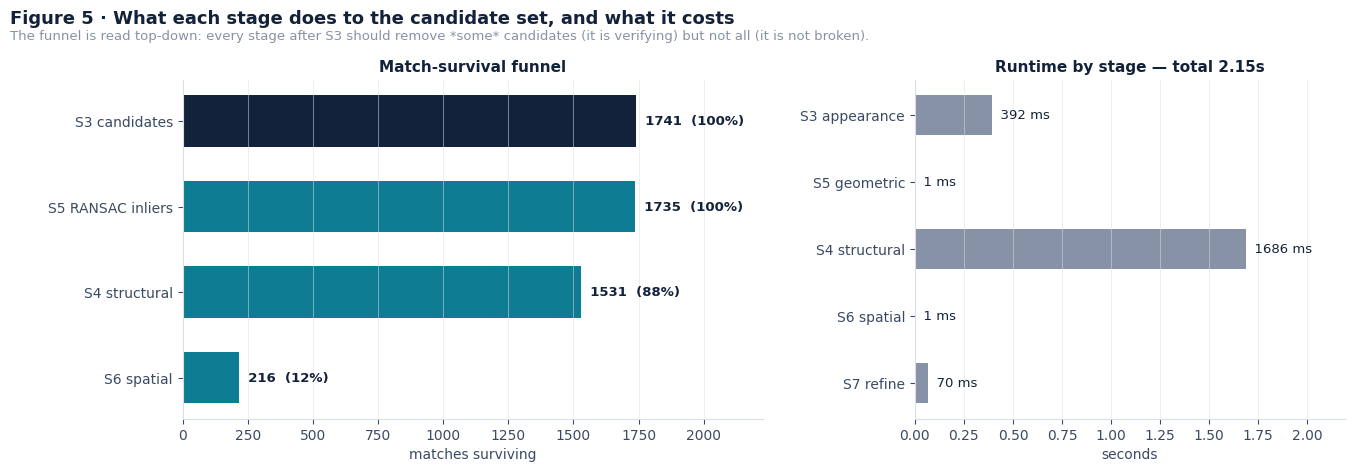

In [27]:
fig = plt.figure(figsize=(15, 4.4)); gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1], wspace=0.3)

# funnel
ax = fig.add_subplot(gs[0, 0])
labels, vals = list(C.keys()), list(C.values())
bars = ax.barh(range(len(vals))[::-1], vals, color=[NAVY] + [TEAL] * (len(vals) - 1), height=0.6)
ax.set_yticks(range(len(vals))[::-1]); ax.set_yticklabels(labels); ax.grid(axis="y", visible=False)
for i, v in enumerate(vals):
    ax.text(v, len(vals) - 1 - i, f"  {v}" + (f"  ({100 * v / vals[0]:.0f}%)" if vals[0] else ""), va="center", fontsize=9.5, color=NAVY, weight="bold")
ax.set_xlim(0, max(vals) * 1.28 if vals and max(vals) else 1); ax.set_xlabel("matches surviving"); ax.set_title("Match-survival funnel")

# runtime
ax = fig.add_subplot(gs[0, 1])
tl, tv = list(T.keys()), list(T.values())
ax.barh(range(len(tv))[::-1], tv, color=GREY, height=0.6)
ax.set_yticks(range(len(tv))[::-1]); ax.set_yticklabels(tl); ax.grid(axis="y", visible=False)
for i, v in enumerate(tv):
    ax.text(v, len(tv) - 1 - i, f"  {v * 1000:.0f} ms", va="center", fontsize=9.5, color=NAVY)
ax.set_xlim(0, max(tv) * 1.3 if tv else 1); ax.set_xlabel("seconds"); ax.set_title(f"Runtime by stage — total {M['runtime_s']:.2f}s")

fig_title(fig, "Figure 5 · What each stage does to the candidate set, and what it costs",
          "The funnel is read top-down: every stage after S3 should remove *some* candidates (it is verifying) but not all (it is not broken).", y=1.04)
plt.show()

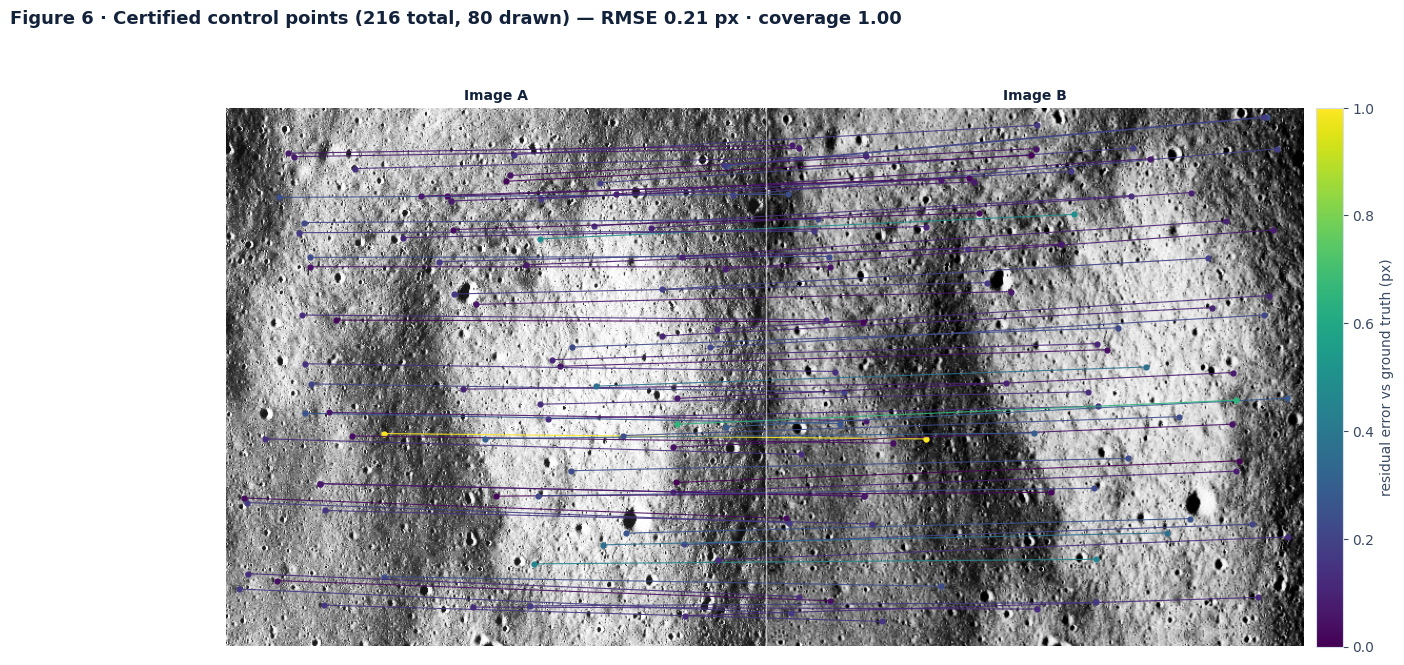

In [28]:
def plot_matches(img_a, img_b, pts_a, pts_b, err, title, max_lines=80):
    h, w = img_a.shape
    canvas = np.hstack([img_a, img_b])
    fig, ax = plt.subplots(figsize=(15, 7)); ax.imshow(canvas, cmap="gray", vmin=0, vmax=255); ax.set_axis_off(); ax.grid(False)
    if len(pts_a):
        norm = mcolors.Normalize(vmin=0, vmax=max(1.0, float(np.percentile(err, 95))))
        idx = np.random.default_rng(0).choice(len(pts_a), size=min(max_lines, len(pts_a)), replace=False)
        for i in idx:
            c = cm.viridis(norm(err[i]))
            ax.plot([pts_a[i, 0], pts_b[i, 0] + w], [pts_a[i, 1], pts_b[i, 1]], color=c, lw=0.8, alpha=0.9)
            ax.plot(pts_a[i, 0], pts_a[i, 1], "o", ms=3.5, color=c); ax.plot(pts_b[i, 0] + w, pts_b[i, 1], "o", ms=3.5, color=c)
        cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax, fraction=0.025, pad=0.01)
        cb.set_label("residual error vs ground truth (px)")
    ax.axvline(w, color="white", lw=1, alpha=0.6)
    ax.text(w * 0.5, -8, "Image A", ha="center", color=NAVY, weight="bold"); ax.text(w * 1.5, -8, "Image B", ha="center", color=NAVY, weight="bold")
    fig_title(fig, title, y=1.02); plt.show()

if len(res["pts_a"]):
    plot_matches(imgA_demo, imgB_demo, res["pts_a"], res["pts_b"], res["errors"],
                 f"Figure 6 · Certified control points ({M['n_matches']} total, {min(80, M['n_matches'])} drawn) — RMSE {M['rmse_px']:.2f} px · coverage {M['grid_occupied_frac']:.2f}")
else:
    print("No certified matches survived — lower the illumination proxy or pick another source image.")

### Coverage and error distribution

Two things the PS explicitly cares about, made visible. Left pair: the spatial distribution of matches **before and after Stage 6** — the whole point of that stage is to turn a clustered set into a spread one. Right pair: the residual-error distribution **before and after Stage 7** — the whole point of that stage is to push mass below the 1-px line.

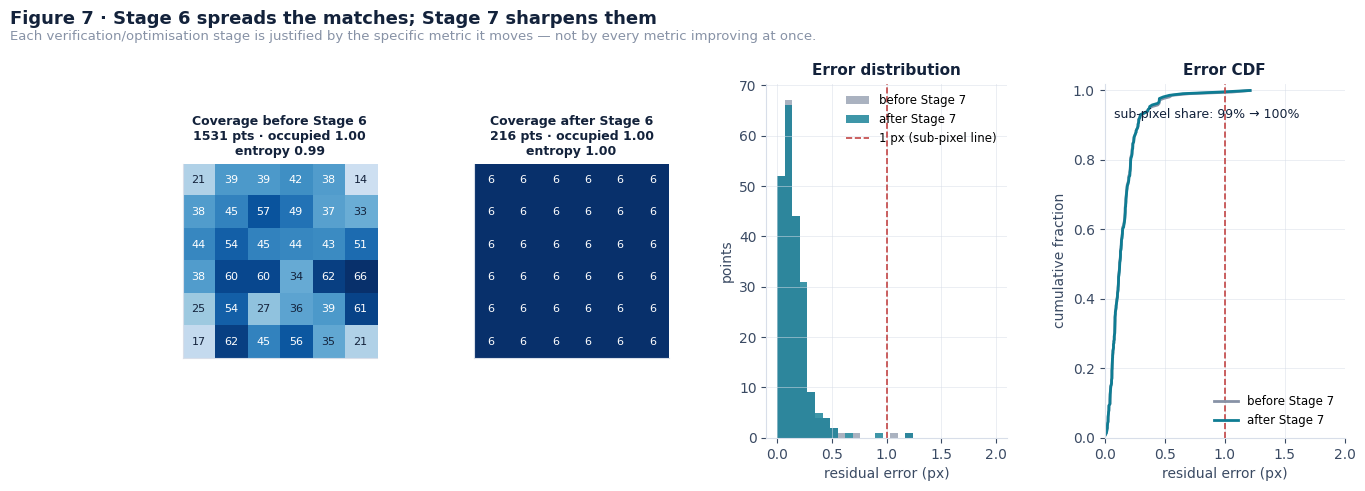

In [29]:
fig = plt.figure(figsize=(15, 4.6)); gs = fig.add_gridspec(1, 4, width_ratios=[1.05, 1.05, 1.3, 1.3], wspace=0.45)
size = imgA_demo.shape[0]

for j, (pts, lab) in enumerate([(res["pts_a_pre_spatial"], "before Stage 6"), (res["pts_a"], "after Stage 6")]):
    occ, ent, grid = coverage_stats(pts, size)
    ax = fig.add_subplot(gs[0, j]); ax.grid(False)
    im = ax.imshow(grid, cmap="Blues", vmin=0); ax.set_xticks([]); ax.set_yticks([])
    for (r, c), v in np.ndenumerate(grid):
        ax.text(c, r, int(v), ha="center", va="center", fontsize=8, color="white" if v > grid.max() * 0.55 else NAVY)
    ax.set_title(f"Coverage {lab}\n{len(pts)} pts · occupied {occ:.2f}\nentropy {ent:.2f}", fontsize=9)

ax = fig.add_subplot(gs[0, 2])
if len(res["errors"]):
    bins = np.linspace(0, max(2.0, float(np.percentile(res["errors_pre"], 98))), 30)
    ax.hist(res["errors_pre"], bins=bins, color=GREY, alpha=0.7, label="before Stage 7")
    ax.hist(res["errors"], bins=bins, color=TEAL, alpha=0.8, label="after Stage 7")
    ax.axvline(1.0, color=CORAL, ls="--", lw=1.2, label="1 px (sub-pixel line)")
    ax.set_xlabel("residual error (px)"); ax.set_ylabel("points"); ax.legend(fontsize=8.5); ax.set_title("Error distribution")

ax = fig.add_subplot(gs[0, 3])
if len(res["errors"]):
    for e, lab, col in [(res["errors_pre"], "before Stage 7", GREY), (res["errors"], "after Stage 7", TEAL)]:
        xs = np.sort(e); ax.plot(xs, np.arange(1, len(xs) + 1) / len(xs), color=col, lw=2, label=lab)
    ax.axvline(1.0, color=CORAL, ls="--", lw=1.2)
    ax.text(0.04, 0.93, f"sub-pixel share: {100 * M['inlier_ratio_pre_refine']:.0f}% → {100 * M['inlier_ratio_subpixel']:.0f}%", transform=ax.transAxes, fontsize=9, color=NAVY, va="top")
    ax.set_xlim(0, max(2.0, float(np.percentile(res["errors_pre"], 98)))); ax.set_ylim(0, 1.02)
    ax.set_xlabel("residual error (px)"); ax.set_ylabel("cumulative fraction"); ax.legend(fontsize=8.5, loc="lower right"); ax.set_title("Error CDF")

fig_title(fig, "Figure 7 · Stage 6 spreads the matches; Stage 7 sharpens them",
          "Each verification/optimisation stage is justified by the specific metric it moves — not by every metric improving at once.", y=1.04)
plt.show()

## §6 · Ablation — what does each stage actually contribute?

The same pipeline run with stages switched off, over the same set of pairs (fixed seeds, moderate difficulty: illumination proxy 0.5, scale ratio 1.3). Four configurations, cumulative:

| Configuration | Stages active |
|---|---|
| Baseline | S3 appearance + S5 RANSAC (what a "SIFT + RANSAC" solution is) |
| + Structural | adds S4 crater-neighbourhood verification |
| + Spatial | adds S6 grid-quota selection |
| Full LunaTech | adds S7 sub-pixel refinement |

The expected signature, if the design is right: **Structural** raises the sub-pixel inlier ratio (fewer wrong-but-plausible matches), **Spatial** raises coverage (at the cost of raw match count — that trade is the point), **Refine** lowers RMSE. Read the actual numbers below against that expectation; the honest answer is whatever the bars say.

In [30]:
ABLATION = [("Baseline (S3+S5)", dict(use_structural=False, use_spatial=False, use_refine=False)),
            ("+ Structural (S4)", dict(use_structural=True, use_spatial=False, use_refine=False)),
            ("+ Spatial (S6)", dict(use_structural=True, use_spatial=True, use_refine=False)),
            ("Full LunaTech (+S7)", dict(use_structural=True, use_spatial=True, use_refine=True))]

abl_rows = []
for k in range(CFG.n_ablation_pairs):
    seed = 500 + k * 17
    pair = make_pair(grayscale_files[k % len(grayscale_files)], seed=seed, illum_strength=0.5, scale_ratio=1.3)
    if pair is None:
        continue
    for name, flags in ABLATION:
        try:
            m = register(*pair, **flags)["metrics"]
        except Exception as e:
            m = {"n_matches": 0}
        abl_rows.append({"config": name, "pair": k, **{key: m.get(key, np.nan) for key in ("n_matches", "rmse_px", "inlier_ratio_subpixel", "grid_occupied_frac", "grid_entropy_norm", "runtime_s")}})

abl_df = pd.DataFrame(abl_rows)
order = [n for n, _ in ABLATION]
abl_summary = abl_df.groupby("config").agg(["mean", "std"]).drop(columns="pair").reindex(order)
abl_mean = abl_df.groupby("config").mean(numeric_only=True).drop(columns="pair").reindex(order)

print(f"Ablation over {abl_df['pair'].nunique()} pairs × {len(ABLATION)} configurations")
try:
    display(abl_mean.style.format("{:.3f}").background_gradient(cmap="Blues", axis=0).set_caption("Mean over pairs (per-config)"))
except Exception:
    display(abl_mean.round(3))

Ablation over 10 pairs × 4 configurations


,n_matches,rmse_px,inlier_ratio_subpixel,grid_occupied_frac,grid_entropy_norm,runtime_s
config,,,,,,
Baseline (S3+S5),1147.300,0.316,0.987,0.856,0.861,0.294
+ Structural (S4),945.100,0.315,0.987,0.847,0.855,1.502
+ Spatial (S6),176.300,0.237,0.996,0.847,0.879,1.511
Full LunaTech (+S7),176.300,0.224,0.998,0.847,0.879,1.553


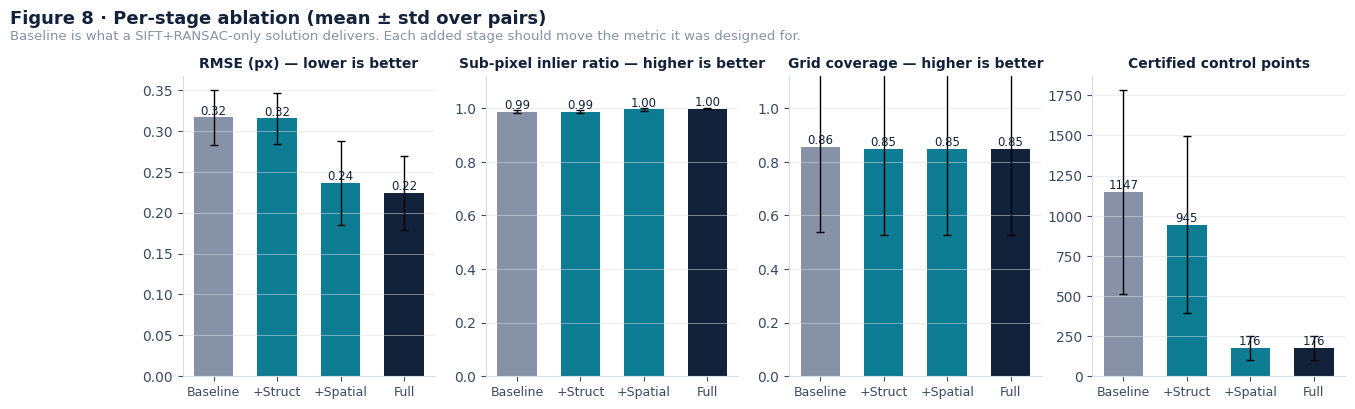

In [31]:
panels = [("rmse_px", "RMSE (px) — lower is better", True), ("inlier_ratio_subpixel", "Sub-pixel inlier ratio — higher is better", False),
          ("grid_occupied_frac", "Grid coverage — higher is better", False), ("n_matches", "Certified control points", False)]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.9)); cols = [GREY, TEAL, TEAL, NAVY]
for ax, (key, title, lower) in zip(axes, panels):
    mean, std = abl_summary[(key, "mean")].values, abl_summary[(key, "std")].values
    ax.bar(range(len(order)), mean, yerr=np.nan_to_num(std), color=cols, width=0.62, capsize=3, error_kw=dict(lw=1, color=NAVY))
    ax.set_xticks(range(len(order))); ax.set_xticklabels(["Baseline", "+Struct", "+Spatial", "Full"], fontsize=9); ax.grid(axis="x", visible=False)
    for i, v in enumerate(mean):
        if np.isfinite(v):
            ax.text(i, v, f"{v:.2f}" if key != "n_matches" else f"{v:.0f}", ha="center", va="bottom", fontsize=8.5, color=NAVY)
    ax.set_title(title, fontsize=10)
    if key in ("inlier_ratio_subpixel", "grid_occupied_frac"):
        ax.set_ylim(0, 1.12)
fig_title(fig, "Figure 8 · Per-stage ablation (mean ± std over pairs)",
          "Baseline is what a SIFT+RANSAC-only solution delivers. Each added stage should move the metric it was designed for.", y=1.05)
plt.show()

## §7 · Stress matrix — where does it hold and where does it break?

Illumination-proxy strength (0 = identical tone, 1 = large brightness/gamma/contrast shift) × scale ratio, **each cell averaged over several independently sampled pairs** so a lucky or unlucky crop doesn't set the number. Reported as three heatmaps — one per PS criterion — plus RMSE-vs-illumination curves.

This is deliberately a *map of failure*, not a single score: the region where the metrics degrade is as much a result as the region where they hold.

In [32]:
illum_levels = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
scale_levels = [1.0, 1.5, 2.0]

rows = []
for illum, scale in itertools.product(illum_levels, scale_levels):
    for rep in range(CFG.stress_repeats):
        seed = int(illum * 100) * 7 + int(scale * 10) * 13 + rep * 101 + 3000
        pair = make_pair(grayscale_files[seed % len(grayscale_files)], seed=seed, illum_strength=illum, scale_ratio=scale)
        if pair is None:
            continue
        try:
            m = register(*pair)["metrics"]
        except Exception:
            m = {"n_matches": 0}
        rows.append({"illum": illum, "scale": scale, "rep": rep, **{k: m.get(k, np.nan) for k in ("n_matches", "rmse_px", "inlier_ratio_subpixel", "grid_occupied_frac", "runtime_s")}})

stress_df = pd.DataFrame(rows)
stress_mean = stress_df.groupby(["illum", "scale"]).mean(numeric_only=True).drop(columns="rep").reset_index()
print(f"{len(stress_df)} registrations · {len(illum_levels)}×{len(scale_levels)} cells × {CFG.stress_repeats} repeats")
display(stress_mean.pivot(index="illum", columns="scale", values="rmse_px").round(3).rename_axis(index="illumination proxy", columns="scale ratio"))

54 registrations · 6×3 cells × 3 repeats


scale ratio,1.0,1.5,2.0
illumination proxy,,,
0.0,0.179,0.238,0.200
0.2,0.210,0.226,0.388
0.4,0.199,0.245,0.285
0.6,0.198,0.253,0.317
0.8,0.208,0.250,0.322
1.0,0.222,0.311,0.338


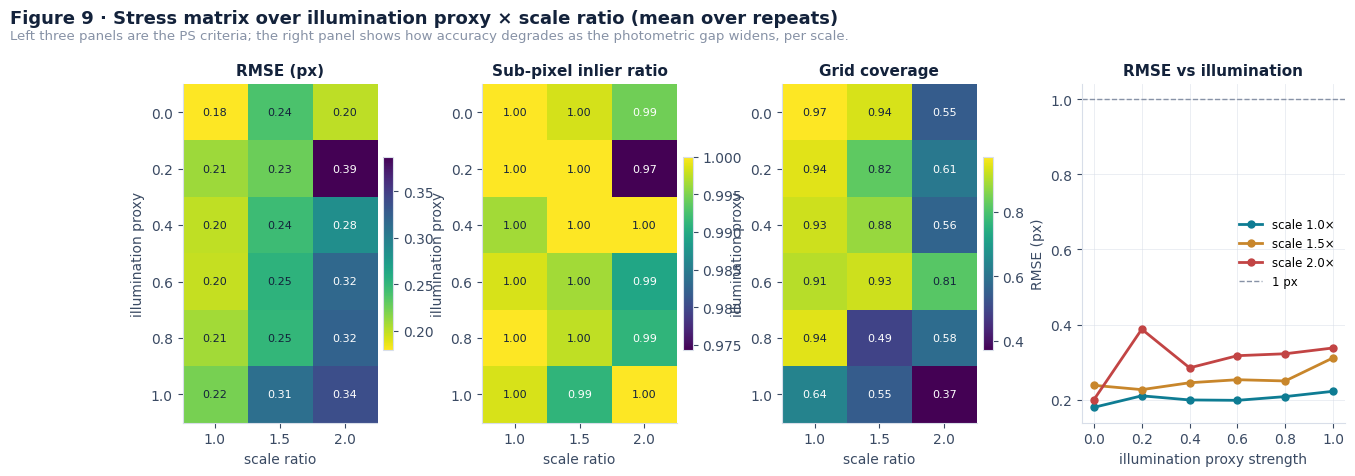

In [33]:
fig = plt.figure(figsize=(15, 4.4)); gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.25], wspace=0.4)
specs = [("rmse_px", "RMSE (px)", "viridis_r"), ("inlier_ratio_subpixel", "Sub-pixel inlier ratio", "viridis"), ("grid_occupied_frac", "Grid coverage", "viridis")]
for j, (key, title, cmap) in enumerate(specs):
    piv = stress_mean.pivot(index="illum", columns="scale", values=key)
    ax = fig.add_subplot(gs[0, j]); ax.grid(False)
    im = ax.imshow(piv.values, cmap=cmap, aspect="auto"); fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns); ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    ax.set_xlabel("scale ratio"); ax.set_ylabel("illumination proxy"); ax.set_title(title)
    for (r, c), v in np.ndenumerate(piv.values):
        if np.isfinite(v):
            ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if (v > np.nanmean(piv.values)) == (cmap == "viridis_r") else NAVY)

ax = fig.add_subplot(gs[0, 3])
for s, col in zip(scale_levels, [TEAL, AMBER, CORAL]):
    d = stress_mean[stress_mean["scale"] == s]
    ax.plot(d["illum"], d["rmse_px"], "-o", color=col, lw=2, ms=5, label=f"scale {s}×")
ax.axhline(1.0, color=GREY, ls="--", lw=1, label="1 px")
ax.set_xlabel("illumination proxy strength"); ax.set_ylabel("RMSE (px)"); ax.set_title("RMSE vs illumination"); ax.legend(fontsize=8.5)

fig_title(fig, "Figure 9 · Stress matrix over illumination proxy × scale ratio (mean over repeats)",
          "Left three panels are the PS criteria; the right panel shows how accuracy degrades as the photometric gap widens, per scale.", y=1.05)
plt.show()

## §8 · Results scorecard

Headline numbers, generated from the runs above — not typed in.

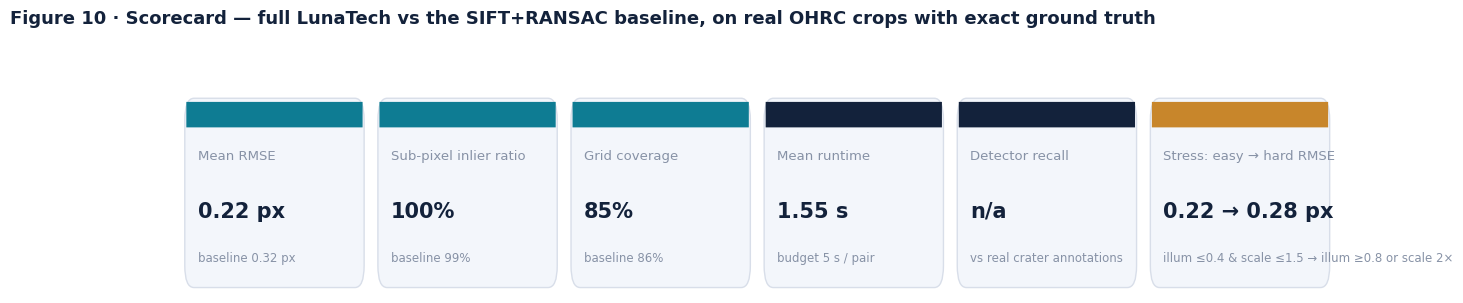


**Summary (auto-generated from this run).** Over 10 real-imagery pairs at moderate difficulty, the full pipeline reaches
**RMSE 0.22 px** (baseline 0.32 px), a **sub-pixel inlier ratio of 100%**
(baseline 99%), and **grid coverage of 85%** (baseline 86%),
in 1.55 s per pair. Across the stress matrix, mean RMSE moves from 0.22 px in the easy regime to
0.28 px in the hard regime — that degradation curve is the operating envelope of the current prototype.



In [34]:
full = abl_mean.loc["Full LunaTech (+S7)"]; base = abl_mean.loc["Baseline (S3+S5)"]
easy = stress_mean[(stress_mean["illum"] <= 0.4) & (stress_mean["scale"] <= 1.5)]
hard = stress_mean[(stress_mean["illum"] >= 0.8) | (stress_mean["scale"] >= 2.0)]

cards = [("Mean RMSE", f"{full['rmse_px']:.2f} px", f"baseline {base['rmse_px']:.2f} px", TEAL),
         ("Sub-pixel inlier ratio", f"{100 * full['inlier_ratio_subpixel']:.0f}%", f"baseline {100 * base['inlier_ratio_subpixel']:.0f}%", TEAL),
         ("Grid coverage", f"{100 * full['grid_occupied_frac']:.0f}%", f"baseline {100 * base['grid_occupied_frac']:.0f}%", TEAL),
         ("Mean runtime", f"{full['runtime_s']:.2f} s", f"budget {CFG.runtime_budget_s:.0f} s / pair", NAVY),
         ("Detector recall", f"{detector_recall_mean:.2f}" if np.isfinite(detector_recall_mean) else "n/a", "vs real crater annotations", NAVY),
         ("Stress: easy → hard RMSE", f"{easy['rmse_px'].mean():.2f} → {hard['rmse_px'].mean():.2f} px", "illum ≤0.4 & scale ≤1.5 → illum ≥0.8 or scale 2×", AMBER)]

fig, ax = plt.subplots(figsize=(15, 2.6)); ax.set_axis_off(); ax.grid(False)
w, gap = 2.3, 0.22
for i, (lab, big, sub, col) in enumerate(cards):
    x = i * (w + gap)
    ax.add_patch(FancyBboxPatch((x, 0), w, 1, boxstyle="round,pad=0.02,rounding_size=0.12", fc="#F3F6FB", ec=LINE, lw=1))
    ax.add_patch(FancyBboxPatch((x, 0.86), w, 0.14, boxstyle="round,pad=0,rounding_size=0.0", fc=col, ec="none"))
    ax.text(x + 0.15, 0.7, lab, fontsize=9.5, color=GREY, va="center")
    ax.text(x + 0.15, 0.4, big, fontsize=15, color=NAVY, weight="bold", va="center")
    ax.text(x + 0.15, 0.14, sub, fontsize=8.5, color=GREY, va="center")
ax.set_xlim(-0.05, len(cards) * (w + gap)); ax.set_ylim(-0.05, 1.05)
fig_title(fig, "Figure 10 · Scorecard — full LunaTech vs the SIFT+RANSAC baseline, on real OHRC crops with exact ground truth", y=1.2)
plt.show()

display(Markdown(f'''
**Summary (auto-generated from this run).** Over {abl_df["pair"].nunique()} real-imagery pairs at moderate difficulty, the full pipeline reaches
**RMSE {full["rmse_px"]:.2f} px** (baseline {base["rmse_px"]:.2f} px), a **sub-pixel inlier ratio of {100 * full["inlier_ratio_subpixel"]:.0f}%**
(baseline {100 * base["inlier_ratio_subpixel"]:.0f}%), and **grid coverage of {100 * full["grid_occupied_frac"]:.0f}%** (baseline {100 * base["grid_occupied_frac"]:.0f}%),
in {full["runtime_s"]:.2f} s per pair. Across the stress matrix, mean RMSE moves from {easy["rmse_px"].mean():.2f} px in the easy regime to
{hard["rmse_px"].mean():.2f} px in the hard regime — that degradation curve is the operating envelope of the current prototype.
{"**Note: these numbers come from the synthetic fallback stand-in, not real OHRC data — rerun on Kaggle with the dataset attached.**" if USING_FALLBACK else ""}
'''))

## §10 · Export for the frontend

Writes the demo pair's images, per-stage survivors and metrics to JSON so the LunaTech site can draw the *real* matches. Run last; copy the three output files into `frontend/public/data/`.

In [ ]:
# ============================================================================
# §10 · Export the demo pair for the LunaTech frontend  (run LAST)
# Writes lunatech_export.json + lunatech_A.png + lunatech_B.png.
# On Kaggle they land in /kaggle/working/lunatech_export/ -> copy the three files
# into  frontend/public/data/  and reload the site.
# The pair is exactly the §3/§5 demo pair; every number in the JSON is measured
# against the exact ground-truth homography, nothing is typed in by hand.
# ============================================================================
import json, datetime

EXPORT_DIR = "/kaggle/working/lunatech_export" if os.path.isdir("/kaggle/working") else "lunatech_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

A, B, H_gt = imgA_demo, imgB_demo, H_gt_demo          # same pair as §3-§5
size = A.shape[0]

# --- replay the stages in register()'s order, keeping every stage's survivors ----
ca, cb, conf = match_sift(A, B, CFG)                                # S3 candidates
mask5, H_est = geometric_verify(ca, cb, CFG)                        # S5 RANSAC
i5 = np.flatnonzero(mask5)
a5, b5, c5 = ca[i5], cb[i5], conf[i5]
sm = structural_consistency(a5, b5, detect_blobs(A, CFG), detect_blobs(B, CFG), CFG)   # S4 structural
i4 = i5[sm]
a4, b4, c4 = ca[i4], cb[i4], conf[i4]
cn = (c4 - c4.min()) / (c4.max() - c4.min() + 1e-9) if len(c4) else c4
sel = spatial_optimize(a4, cn, size, CFG)                           # S6 spatial
i6 = i4[sel]
a6, b6 = ca[i6], cb[i6]
b6_ref = subpixel_refine(A, B, a6, b6, H_est, CFG)                  # S7 refine

# --- guard: the replay must equal what register() reports in §5 --------------------
ref = register(A, B, H_gt)
same = (len(ref["pts_a"]) == len(a6)) and np.allclose(ref["pts_a"], a6) and np.allclose(ref["pts_b"], b6_ref)
print("replay matches register():", same)
assert same, "stage replay diverged from register() - do not export"

def r2(x, n=2):
    return np.round(np.asarray(x, dtype=float), n).tolist()

metrics = compute_metrics(a6, b6_ref, H_gt, size, CFG)
pre = compute_metrics(a6, b6, H_gt, size, CFG)
clean = lambda d: {k: (None if isinstance(v, float) and not np.isfinite(v) else v) for k, v in d.items()}

export = {
    "schema": 1,
    "provenance": {
        "source": "synthetic-fallback" if USING_FALLBACK else "real-ohrc",
        "source_file": os.path.basename(grayscale_files[0]),
        "ground_truth": "synthetic warp: known homography applied to one real crop",
        "seed": 7, "illum_strength": DEMO_ILLUM, "scale_ratio": DEMO_SCALE,
        "generated_utc": datetime.datetime.utcnow().isoformat(timespec="seconds") + "Z",
        "opencv": cv2.__version__,
    },
    "image_size": int(size),
    "grid_size": CFG.grid_size,
    "ransac_thresh_px": CFG.ransac_reproj_thresh,
    "H_gt": r2(H_gt, 8),
    # S3 candidates: A/B positions + error vs ground truth (px). Later stages are index lists into these.
    "cand_a": r2(ca), "cand_b": r2(cb), "cand_err": r2(point_errors(ca, cb, H_gt)),
    "idx": {"S5": i5.tolist(), "S4": i4.tolist(), "S6": i6.tolist()},
    # Final certified points (after S7 refinement), same order as idx["S6"]
    "final_b": r2(b6_ref, 3), "final_err": r2(point_errors(a6, b6_ref, H_gt), 3),
    "final_err_pre_refine": r2(point_errors(a6, b6, H_gt), 3),
    "metrics": clean(metrics),
    "metrics_pre_refine": clean(pre),
    "timings_s": {k: round(v, 4) for k, v in ref["timings"].items()},
}
with open(os.path.join(EXPORT_DIR, "lunatech_export.json"), "w") as f:
    json.dump(export, f, allow_nan=False, separators=(",", ":"))
cv2.imwrite(os.path.join(EXPORT_DIR, "lunatech_A.png"), A)
cv2.imwrite(os.path.join(EXPORT_DIR, "lunatech_B.png"), B)

print(f"source: {export['provenance']['source']} | {os.path.basename(grayscale_files[0])}")
print(f"funnel: S3 {len(ca)} -> S5 {len(i5)} -> S4 {len(i4)} -> S6 {len(i6)} (S7 refines, removes none)")
print(f"RMSE {metrics['rmse_px']:.3f} px | sub-pixel {metrics['inlier_ratio_subpixel']:.3f} | coverage {metrics['grid_occupied_frac']:.3f}")
print("wrote:", sorted(os.listdir(EXPORT_DIR)), "->", EXPORT_DIR)
